In [1]:

import numpy as np 
import sympy as sp 
import scipy
import matplotlib.pyplot as plt

# part 1, q3

In [2]:
t = sp.Symbol('t')
l = sp.Symbol('l')
theta = sp.Function('theta')(t)
R = sp.Matrix([[sp.cos(theta), -sp.sin(theta), 0],
              [sp.sin(theta), sp.cos(theta), 0],
              [0,0,1]])

p = sp.Matrix([[1/2*l*sp.cos(theta)],[1/2*l*sp.sin(theta)], [0]])

T = sp.Matrix([[sp.cos(theta), -sp.sin(theta), 0, 1/2*l*sp.cos(theta)], [sp.sin(theta), sp.cos(theta), 0, 1/2*l*sp.sin(theta)], [0,0,1,0], [0,0,0,1]])
T_diff = T.diff('t')

Vb = sp.Matrix([[sp.cos(theta), sp.sin(theta), 0, -0.5*l], 
                [-sp.sin(theta), sp.cos(theta), 0,0], 
                [0,0,1,0],
                [0,0,0,1]]) @ T_diff
Vb.simplify()
Vb

Vs = T_diff @ sp.Matrix([[sp.cos(theta), sp.sin(theta), 0, -0.5*l], 
                [-sp.sin(theta), sp.cos(theta), 0,0], 
                [0,0,1,0],
                [0,0,0,1]])

Vs.simplify()
Vs


Matrix([
[                      0, -Derivative(theta(t), t), 0, 0],
[Derivative(theta(t), t),                        0, 0, 0],
[                      0,                        0, 0, 0],
[                      0,                        0, 0, 0]])

# Part 2 


In [3]:

def cross_matrix(vec):
    x,y,z = vec[0], vec[1], vec[2]
    return np.array([
        [0, -z, y],
        [z, 0, -x],
        [-y,x,0]
        ])


In [4]:
def uncross_matrix(matrix):
    return np.array([matrix[2,1], matrix[0,2], matrix[1,0]])

In [5]:
def omega_dot(t,omega,Ib):
    omega_d = -np.linalg.inv(Ib) @ (cross_matrix(omega) @ (Ib @omega)) 
    return omega_d.flatten()

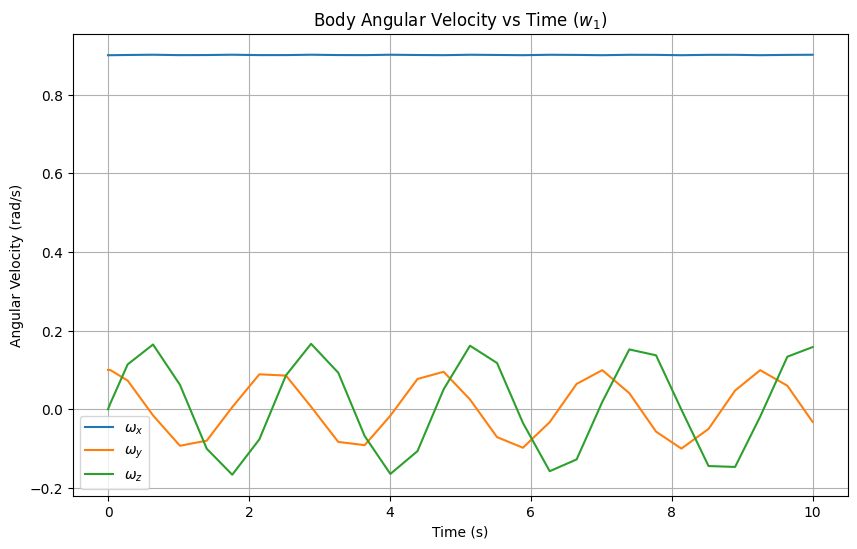

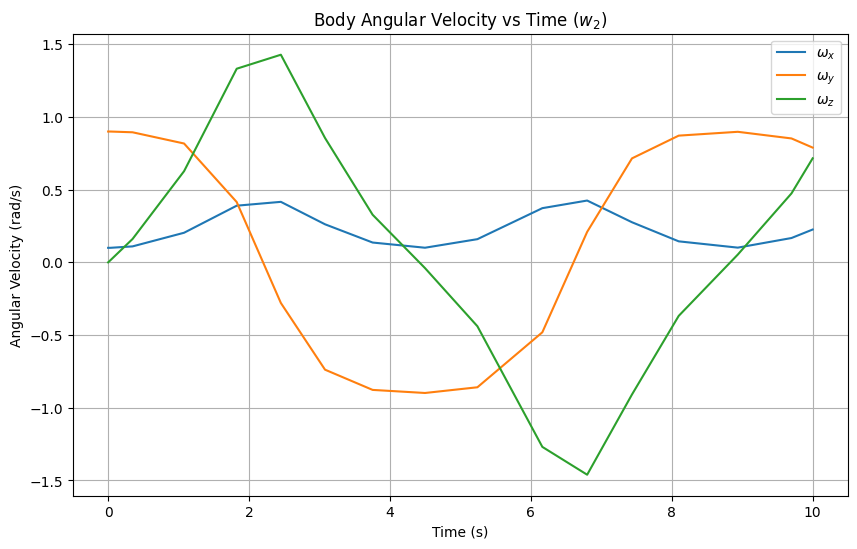

In [6]:
w1 = np.array([0.9,0.1,0])
Ib = np.array([[10,0,0], [0,5,0], [0,0,1]])
sol1 = scipy.integrate.solve_ivp(lambda t,w: omega_dot(t,w,Ib), [0,10], w1)

plt.figure(figsize=(10,6))
plt.plot(sol1.t, sol1.y[0], label='$\omega_x$')
plt.plot(sol1.t, sol1.y[1], label='$\omega_y$')
plt.plot(sol1.t, sol1.y[2], label='$\omega_z$')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.title('Body Angular Velocity vs Time ($w_1$)')
plt.legend()
plt.grid(True)
plt.show()


w2 = np.array([0.1,0.9,0])
sol2 = scipy.integrate.solve_ivp(lambda t,w: omega_dot(t,w,Ib), [0,10], w2)

plt.figure(figsize=(10,6))
plt.plot(sol2.t, sol2.y[0], label='$\omega_x$')
plt.plot(sol2.t, sol2.y[1], label='$\omega_y$')
plt.plot(sol2.t, sol2.y[2], label='$\omega_z$')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.title('Body Angular Velocity vs Time ($w_2$)')
plt.legend()
plt.grid(True)
plt.show()



/var/folders/zl/w4c_xm7169zfb43bbsvrlsdr0000gn/T/ipykernel_96374/1917462007.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


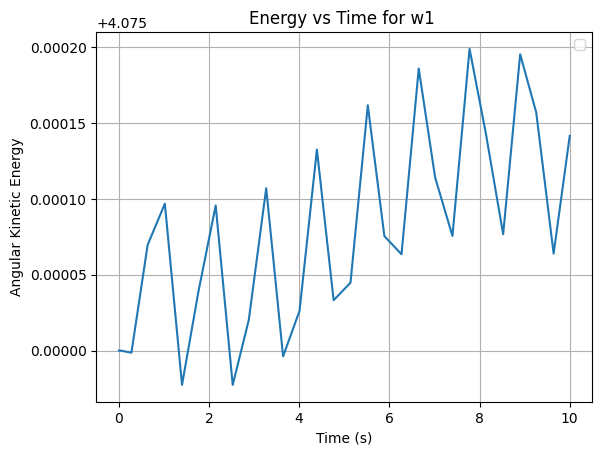

/var/folders/zl/w4c_xm7169zfb43bbsvrlsdr0000gn/T/ipykernel_96374/1917462007.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


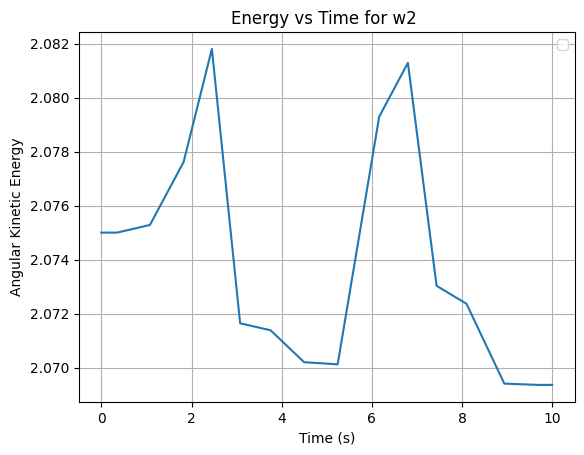

In [7]:
KE1 = 0.5 * np.sum(sol1.y * (Ib @ sol1.y), axis=0)
plt.plot(sol1.t, KE1)
plt.xlabel('Time (s)')
plt.ylabel('Angular Kinetic Energy')
plt.title('Energy vs Time for w1 ')
plt.legend()
plt.grid(True)
plt.show()



KE2 = 0.5 * np.sum(sol2.y * (Ib @ sol2.y), axis=0)
plt.plot(sol2.t, KE2)
plt.xlabel('Time (s)')
plt.ylabel('Angular Kinetic Energy')
plt.title('Energy vs Time for w2 ')
plt.legend()
plt.grid(True)
plt.show()


# Part 3

In [8]:
# 5
t = sp.symbols('t')
x = sp.Function('x') (t)
y = sp.Function('y') (t) 
l = sp.Function('l') (t)
m1 = sp.Symbol('m1')
m2 = sp.Symbol('m2')
Ib = sp.Symbol('Ib')
theta = sp.Function('theta')(t)
phi = sp.Function('phi')(t)
g = sp.Symbol('g')

x2 = x + l*sp.sin(theta - phi)
y2 = y - l*sp.cos(theta - phi )
x2 = x + l * sp.sin(theta - phi)
y2 = y - l * sp.cos(theta - phi)


KE1 = 0.5 * (2*m1) * (x.diff(t)**2 + y.diff(t)**2) + 0.5 * Ib * theta.diff(t)**2
KE2 = 0.5 * m2 * (x2.diff(t)**2 + y2.diff(t)**2)

KE = KE1 + KE2


PE1 = (2*m1)*g*y 
PE2 = m2*g*y2 
PE = PE1 + PE2 


Lagrangian_dynamics = KE - PE
Lagrangian_dynamics.simplify()

0.5*Ib*Derivative(theta(t), t)**2 - 2*g*m1*y(t) + g*m2*(l(t)*cos(phi(t) - theta(t)) - y(t)) + 1.0*m1*(Derivative(x(t), t)**2 + Derivative(y(t), t)**2) + 0.5*m2*(((Derivative(phi(t), t) - Derivative(theta(t), t))*l(t)*sin(phi(t) - theta(t)) - cos(phi(t) - theta(t))*Derivative(l(t), t) + Derivative(y(t), t))**2 + ((Derivative(phi(t), t) - Derivative(theta(t), t))*l(t)*cos(phi(t) - theta(t)) + sin(phi(t) - theta(t))*Derivative(l(t), t) - Derivative(x(t), t))**2)

In [11]:
#6
eom_y = sp.diff(sp.diff(Lagrangian_dynamics, y.diff(t)), t) - sp.diff(Lagrangian_dynamics, y)
eom_y = sp.nsimplify(eom_y)

eom_x = sp.diff(sp.diff(Lagrangian_dynamics, x.diff(t)), t) - sp.diff(Lagrangian_dynamics, x)
eom_x = sp.nsimplify(eom_x)

eom_l = sp.diff(sp.diff(Lagrangian_dynamics, l.diff(t)), t) - sp.diff(Lagrangian_dynamics, l)
eom_l = sp.nsimplify(eom_l)

eom_theta = sp.diff(sp.diff(Lagrangian_dynamics, theta.diff(t)), t) - sp.diff(Lagrangian_dynamics, theta)
eom_theta = sp.nsimplify(eom_theta)

eom_phi = sp.diff(sp.diff(Lagrangian_dynamics, phi.diff(t)), t) - sp.diff(Lagrangian_dynamics, phi)
eom_phi = sp.nsimplify(eom_phi)

H = sp.Matrix([eom_x, eom_y,eom_theta,eom_phi,eom_l])
q_ddot = sp.Matrix([x.diff(t,t), y.diff(t,t), theta.diff(t,t), phi.diff(t,t), l.diff(t,t)])

C_G = H.subs([(a, 0) for a in q_ddot])

C_G = sp.simplify(C_G)

M = H.jacobian(q_ddot)
M.simplify()



M



Matrix([
[                      2*m1 + m2,                               0,  m2*l(t)*cos(phi(t) - theta(t)), -m2*l(t)*cos(phi(t) - theta(t)), -m2*sin(phi(t) - theta(t))],
[                              0,                       2*m1 + m2, -m2*l(t)*sin(phi(t) - theta(t)),  m2*l(t)*sin(phi(t) - theta(t)), -m2*cos(phi(t) - theta(t))],
[ m2*l(t)*cos(phi(t) - theta(t)), -m2*l(t)*sin(phi(t) - theta(t)),                 Ib + m2*l(t)**2,                     -m2*l(t)**2,                          0],
[-m2*l(t)*cos(phi(t) - theta(t)),  m2*l(t)*sin(phi(t) - theta(t)),                     -m2*l(t)**2,                      m2*l(t)**2,                          0],
[     -m2*sin(phi(t) - theta(t)),      -m2*cos(phi(t) - theta(t)),                               0,                               0,                         m2]])

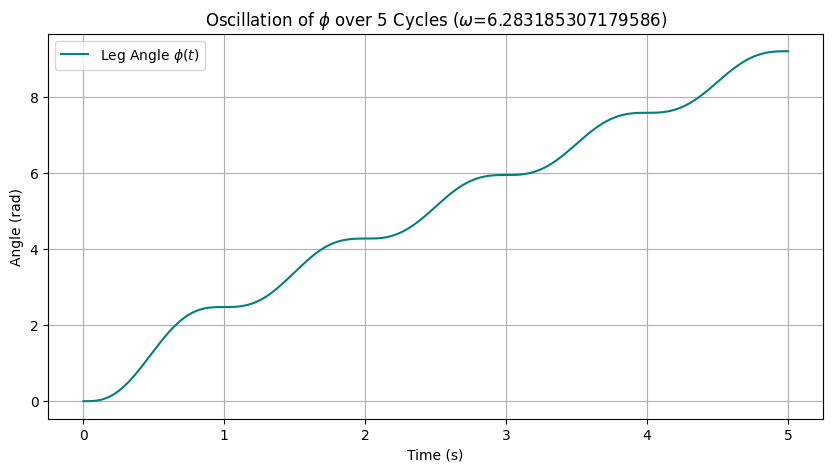

In [10]:
#7
states = [x, y, theta, phi, l, x.diff(t), y.diff(t), theta.diff(t), phi.diff(t), l.diff(t)]
variables = [m1, m2, Ib, g]

M_numpy = sp.lambdify((*states, *variables), M, 'numpy')
CG_numpy = sp.lambdify((*states, *variables), C_G, 'numpy')

def hopper(t,z,m1_val, m2_val, Ib_val, g_val, omega):
    q_dot = z[5:]
    tau_phi = np.sin(omega * t)
    tau_l = np.cos(omega * t)
    tau = np.array([0, 0, 0, tau_phi, tau_l])
    M_eval = np.array(M_numpy(*z, m1_val, m2_val, Ib_val, g_val))
    CG_eval = np.array(CG_numpy(*z, m1_val, m2_val, Ib_val, g_val)).flatten()

    q_ddot = np.linalg.solve(M_eval, tau - CG_eval)
    
    return np.concatenate([q_dot, q_ddot])

omega = 2.0 *np.pi
constants = (1.0, 0.5, 0.1, 9.81, omega) 
z0 = [0, 1.0, 0, 0, 0.5, 0, 0, 0, 0, 0]

t_final = 5 * (2 * np.pi / omega)
t_span = (0, t_final)
t_eval = np.linspace(0, t_final, 1000)

sol = scipy.integrate.solve_ivp(hopper, t_span, z0, t_eval=t_eval, args=constants, method='RK45')

plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[3], label=r'Leg Angle $\phi(t)$', color='teal')
plt.title(f'Oscillation of $\phi$ over 5 Cycles ($\omega$={omega})')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.grid(True)
plt.legend()
plt.show()
